# Baseline Fraud Classification

Binary target: `Fraudulent` (`0` = legitimate, `1` = fraudulent).

## 1. Imports and Configuration

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = (
    working_directory
    if (working_directory / "app").exists()
    else working_directory.parent
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.ml.preprocessing import build_preprocessor, prepare_features_and_target

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "fraud_detection.csv"
RANDOM_STATE = 42

## 2. Load Dataset

In [2]:
raw_data = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {raw_data.shape}")
raw_data.head()

Raw dataset shape: (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


## 3. Prepare Features and Target

In [3]:
X, y = prepare_features_and_target(raw_data)

print(f"Rows after exact deduplication: {len(X):,}")
print(f"Exact duplicates removed: {len(raw_data) - len(X):,}")
print(f"Model feature count before encoding: {X.shape[1]}")
print(f"Identifier columns present: {set(['Transaction_ID', 'User_ID']).intersection(X.columns)}")
display(pd.DataFrame({"feature": X.columns, "dtype": X.dtypes.astype(str).values}))

Rows after exact deduplication: 50,119
Exact duplicates removed: 881
Model feature count before encoding: 9
Identifier columns present: set()


,feature,dtype
0,Transaction_Amount,float64
1,Transaction_Type,str
2,Time_of_Transaction,float64
3,Device_Used,str
4,Location,str
5,Previous_Fraudulent_Transactions,int64
6,Account_Age,int64
7,Number_of_Transactions_Last_24H,int64
8,Payment_Method,str


## 4. Stratified Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

def class_distribution(target: pd.Series) -> pd.DataFrame:
    counts = target.value_counts().sort_index()
    return pd.DataFrame({
        "count": counts,
        "percentage": counts.div(len(target)).mul(100),
    }).rename(index={0: "Legitimate (0)", 1: "Fraudulent (1)"})

print("Training target distribution")
display(class_distribution(y_train))
print("Test target distribution")
display(class_distribution(y_test))
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

Training target distribution


,count,percentage
Fraudulent,,
Legitimate (0),38121,95.076693
Fraudulent (1),1974,4.923307


Test target distribution


,count,percentage
Fraudulent,,
Legitimate (0),9531,95.081804
Fraudulent (1),493,4.918196


Training rows: 40,095; test rows: 10,024


## 5. Baseline Pipeline

In [5]:
preprocessor = build_preprocessor(X_train)
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

## 6. Train and Predict

In [6]:
baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)
y_fraud_probability = baseline_pipeline.predict_proba(X_test)[:, 1]

print(f"Predictions generated: {len(y_pred):,}")
print(f"Fraud probabilities generated: {len(y_fraud_probability):,}")

Predictions generated: 10,024
Fraud probabilities generated: 10,024


## 7. Evaluation

In [7]:
metric_values = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_fraud_probability),
}
baseline_results = pd.DataFrame.from_dict(
    metric_values, orient="index", columns=["value"]
)
display(baseline_results.style.format({"value": "{:.4f}"}))

confusion = confusion_matrix(y_test, y_pred, labels=[0, 1])
display(pd.DataFrame(
    confusion,
    index=["Actual legitimate", "Actual fraudulent"],
    columns=["Predicted legitimate", "Predicted fraudulent"],
))

report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Legitimate (0)", "Fraudulent (1)"],
    zero_division=0,
)
print(report)

,value
Accuracy,0.5023
Precision,0.0466
Recall,0.4686
F1-score,0.0848
ROC-AUC,0.4876


,Predicted legitimate,Predicted fraudulent
Actual legitimate,4804,4727
Actual fraudulent,262,231


                precision    recall  f1-score   support

Legitimate (0)       0.95      0.50      0.66      9531
Fraudulent (1)       0.05      0.47      0.08       493

      accuracy                           0.50     10024
     macro avg       0.50      0.49      0.37     10024
  weighted avg       0.90      0.50      0.63     10024



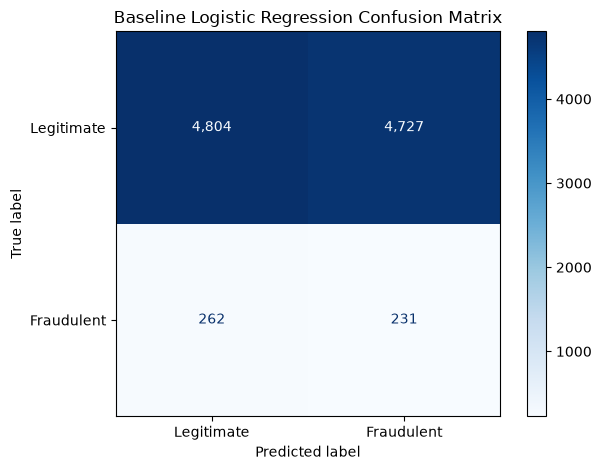

In [8]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Legitimate", "Fraudulent"],
).plot(cmap="Blues", values_format=",d")
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Baseline Model Results

In [9]:
display(baseline_results.style.format({"value": "{:.4f}"}))
print("Confusion matrix [TN, FP, FN, TP]:", confusion.ravel().tolist())
print("These are untuned baseline results using the default 0.5 classification threshold.")

,value
Accuracy,0.5023
Precision,0.0466
Recall,0.4686
F1-score,0.0848
ROC-AUC,0.4876


Confusion matrix [TN, FP, FN, TP]: [4804, 4727, 262, 231]
These are untuned baseline results using the default 0.5 classification threshold.
